Saved: /storage/homefs/sv24v923/MPI_data/clean_pipeline/figures/figure3/Figure_3_network.pdf
Sigma: 0.1378
Connectivity values:
  Mono → Resident
Quiescent: 0.158
  Mono → Scavenging
C1q+: 0.104
  Mono → Fibrotic
Hypoxic: 0.073
  Mono → Foam Cells
Lipid-Stressed: 0.135
  Mono → Inflammatory: 0.140


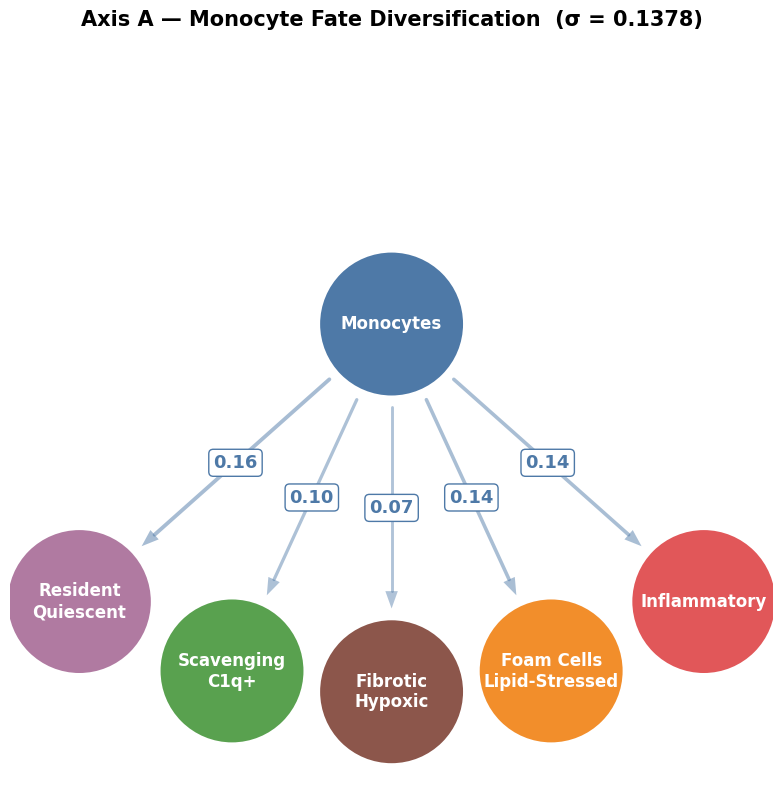

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import numpy as np
import os

# ── Configuration ──
base = "/storage/homefs/sv24v923/MPI_data/clean_pipeline"
out_dir = os.path.join(base, "figures", "figure3")
os.makedirs(out_dir, exist_ok=True)

CLUSTER_COLORS = {
    "Monocytes":                         "#4E79A7",
    "Scavenging / C1q+ Macrophages":     "#59A14F",
    "Resident / Quiescent Macrophages":  "#B07AA1",
    "Inflammatory Macrophages":          "#E15759",
    "Lipid-Stressed / Foam Cells":       "#F28E2B",
    "Fibrotic / Hypoxic Macrophages":    "#8C564B",
}

# ══════════════════════════════════════════════════════════════════
# B=500 CONNECTIVITY — source of truth (Supplementary Table 4)
# ══════════════════════════════════════════════════════════════════
sigma = 0.1378

CONN_B500 = {
    ("Monocytes", "Resident / Quiescent Macrophages"):  0.158,
    ("Monocytes", "Inflammatory Macrophages"):          0.140,
    ("Monocytes", "Lipid-Stressed / Foam Cells"):       0.135,
    ("Monocytes", "Scavenging / C1q+ Macrophages"):     0.104,
    ("Monocytes", "Fibrotic / Hypoxic Macrophages"):    0.073,
}

# ── Equal node radius for every cluster (OT subsamples to 5k) ──
NODE_R = 0.105

# ── Node positions ──
nodes = {
    "Monocytes": {
        "pos": (0.5, 0.65), "color": CLUSTER_COLORS["Monocytes"],
        "size": NODE_R,
    },
    "Resident\nQuiescent": {
        "pos": (0.05, 0.25), "color": CLUSTER_COLORS["Resident / Quiescent Macrophages"],
        "size": NODE_R,
    },
    "Scavenging\nC1q+": {
        "pos": (0.27, 0.15), "color": CLUSTER_COLORS["Scavenging / C1q+ Macrophages"],
        "size": NODE_R,
    },
    "Fibrotic\nHypoxic": {
        "pos": (0.50, 0.12), "color": CLUSTER_COLORS["Fibrotic / Hypoxic Macrophages"],
        "size": NODE_R,
    },
    "Foam Cells\nLipid-Stressed": {
        "pos": (0.73, 0.15), "color": CLUSTER_COLORS["Lipid-Stressed / Foam Cells"],
        "size": NODE_R,
    },
    "Inflammatory": {
        "pos": (0.95, 0.25), "color": CLUSTER_COLORS["Inflammatory Macrophages"],
        "size": NODE_R,
    },
}

# Map from display node names to full cluster names for connectivity lookup
NODE_TO_FULL = {
    "Monocytes":                  "Monocytes",
    "Resident\nQuiescent":        "Resident / Quiescent Macrophages",
    "Scavenging\nC1q+":           "Scavenging / C1q+ Macrophages",
    "Fibrotic\nHypoxic":          "Fibrotic / Hypoxic Macrophages",
    "Foam Cells\nLipid-Stressed": "Lipid-Stressed / Foam Cells",
    "Inflammatory":               "Inflammatory Macrophages",
}

def get_conn(src_display, tgt_display):
    src_full = NODE_TO_FULL[src_display]
    tgt_full = NODE_TO_FULL[tgt_display]
    key = (src_full, tgt_full)
    if key in CONN_B500:
        return CONN_B500[key]
    key_rev = (tgt_full, src_full)
    if key_rev in CONN_B500:
        return CONN_B500[key_rev]
    return None

# ── Edges (all directed from Mono in Axis A) ──
edges = [
    {"src": "Monocytes", "tgt": "Resident\nQuiescent",        "directed": True},
    {"src": "Monocytes", "tgt": "Scavenging\nC1q+",           "directed": True},
    {"src": "Monocytes", "tgt": "Fibrotic\nHypoxic",          "directed": True},
    {"src": "Monocytes", "tgt": "Foam Cells\nLipid-Stressed", "directed": True},
    {"src": "Monocytes", "tgt": "Inflammatory",               "directed": True},
]
for edge in edges:
    edge["conn"] = get_conn(edge["src"], edge["tgt"])

# ══════════════════════════════════════════════════════════════════
# Illustrator-safe arrow: Line2D shaft + filled Polygon head
# Replaces FancyArrowPatch, which renders with bulbous heads in AI
# ══════════════════════════════════════════════════════════════════
def draw_arrow(ax, start, end, color, lw, alpha,
               head_len=0.025, head_width=0.018, directed=True):
    start = np.asarray(start, dtype=float)
    end   = np.asarray(end, dtype=float)
    direction = end - start
    L = np.linalg.norm(direction)
    if L < 1e-9:
        return
    unit = direction / L

    if directed:
        # Shaft stops where the head begins
        shaft_end = end - unit * head_len
        ax.add_line(Line2D([start[0], shaft_end[0]],
                           [start[1], shaft_end[1]],
                           color=color, lw=lw, alpha=alpha,
                           solid_capstyle="round", zorder=2))
        # Triangular head as a filled polygon
        perp = np.array([-unit[1], unit[0]])
        tip   = end
        base  = end - unit * head_len
        left  = base + perp * (head_width / 2)
        right = base - perp * (head_width / 2)
        ax.add_patch(Polygon([tip, left, right], closed=True,
                             facecolor=color, edgecolor=color,
                             linewidth=0, alpha=alpha, zorder=3))
    else:
        # Dashed for undirected
        ax.add_line(Line2D([start[0], end[0]], [start[1], end[1]],
                           color=color, lw=lw, alpha=alpha,
                           linestyle="--", solid_capstyle="round",
                           zorder=1))

# ── Plot ──
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0.0, 1.05)
ax.set_aspect("equal")
ax.axis("off")

# Draw edges
for edge in edges:
    src_pos = np.array(nodes[edge["src"]]["pos"])
    tgt_pos = np.array(nodes[edge["tgt"]]["pos"])
    conn = edge["conn"]
    if conn is None:
        continue

    direction = tgt_pos - src_pos
    dist = np.linalg.norm(direction)
    unit = direction / dist

    src_r = nodes[edge["src"]]["size"]
    tgt_r = nodes[edge["tgt"]]["size"]
    start = src_pos + unit * (src_r + 0.015)
    end   = tgt_pos - unit * (tgt_r + 0.015)

    lw         = 1.5 + conn * 8
    edge_color = nodes[edge["src"]]["color"]
    alpha      = 0.4 + conn * 0.6

    draw_arrow(ax, start, end, edge_color, lw, alpha,
               directed=edge["directed"])

    mid = (start + end) / 2
    ax.text(mid[0], mid[1], f"{conn:.2f}",
            ha="center", va="center", fontsize=13, fontweight="bold",
            color=edge_color,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor=edge_color, linewidth=1, alpha=1.0),
            zorder=10)

# Draw nodes
for name, props in nodes.items():
    circle = plt.Circle(props["pos"], props["size"],
                        color=props["color"], ec="white",
                        linewidth=2, zorder=5)
    ax.add_patch(circle)
    ax.text(props["pos"][0], props["pos"][1], name,
            ha="center", va="center", fontsize=12, fontweight="bold",
            color="white", zorder=6)

ax.set_title(f"Axis A — Monocyte Fate Diversification  (σ = {sigma:.4f})",
             fontsize=15, fontweight="bold", pad=15)

plt.tight_layout()
save_path = os.path.join(out_dir, "Figure_3_network.pdf")
plt.savefig(save_path, bbox_inches="tight", dpi=300, facecolor="white")
print(f"Saved: {save_path}")
print(f"Sigma: {sigma}")
print(f"Connectivity values:")
for edge in edges:
    print(f"  Mono → {edge['tgt']}: {edge['conn']:.3f}")
plt.show()

Saved: /storage/homefs/sv24v923/MPI_data/clean_pipeline/figures/figure3/Figure_3_LOCO_connectivity.pdf


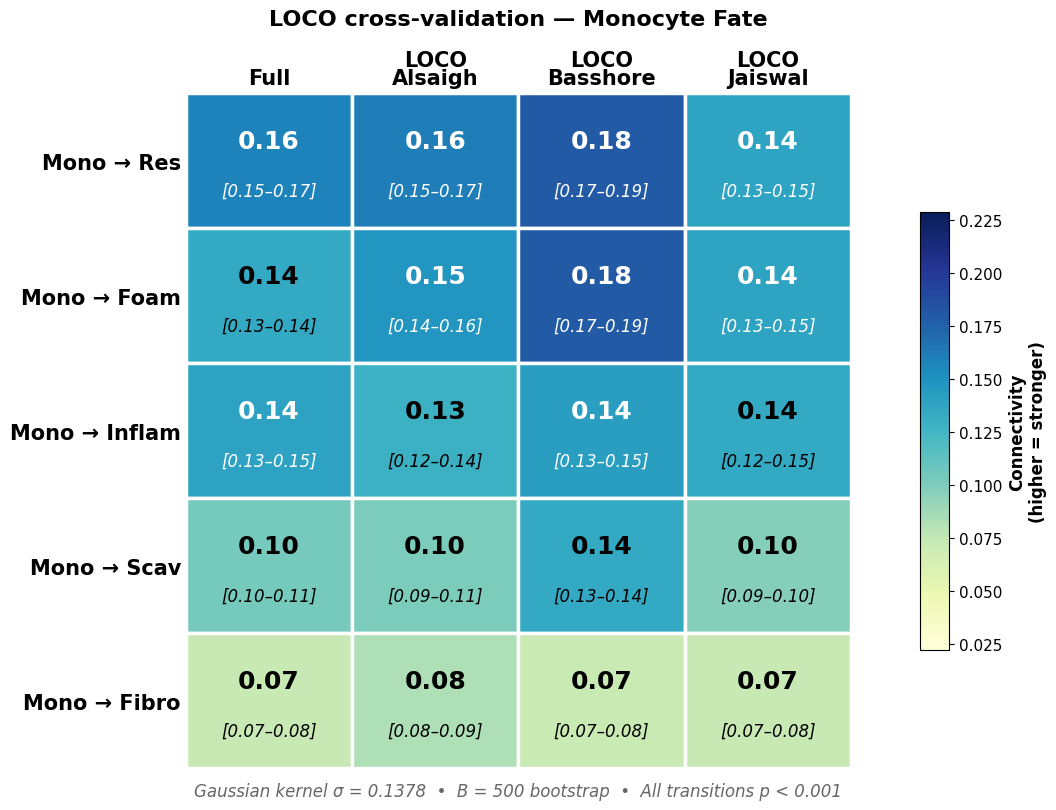

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import os

# ── Configuration ──
base = "/storage/homefs/sv24v923/MPI_data/clean_pipeline"
out_dir = os.path.join(base, "figures", "figure3")
os.makedirs(out_dir, exist_ok=True)

# ══════════════════════════════════════════════════════════════════
# FONT SIZE CONTROLS (tweak these to taste)
# ══════════════════════════════════════════════════════════════════
FS_CONN_VALUE   = 18   # Main connectivity number inside each cell
FS_CI_VALUE     = 12   # CI range below the connectivity value
FS_XTICK        = 15   # Run names along the top (Full, LOCO-Alsaigh, ...)
FS_YTICK        = 15   # Transition labels on the left (Mono -> Res, ...)
FS_TITLE        = 16   # Plot title
FS_CBAR_LABEL   = 12   # Colorbar label
FS_CBAR_TICKS   = 11   # Colorbar tick labels
FS_FOOTNOTE     = 12   # Sigma / bootstrap footnote

# Vertical placement of CI text relative to the cell center
CI_Y_OFFSET     = 0.22

SHORT = {
    "Scavenging / C1q+ Macrophages":    "Scav",
    "Resident / Quiescent Macrophages": "Res",
    "Inflammatory Macrophages":         "Inflam",
    "Lipid-Stressed / Foam Cells":      "Foam",
    "Fibrotic / Hypoxic Macrophages":   "Fibro",
    "Monocytes":                        "Mono",
}

runs_keys    = ["Full", "LOCO-Alsaigh", "LOCO-Bashore", "LOCO-Jaiswal"]
runs_display = ["Full", "LOCO\nAlsaigh", "LOCO\nBasshore", "LOCO\nJaiswal"]

# ── B=500 directories (verify these paths exist on your system) ──
run_paths = {
    "Full":         os.path.join(base, "ot_results_v8_full_500_bootstrap"),
    "LOCO-Alsaigh": os.path.join(base, "ot_results_v8_loco_alsaigh_500_bootstrap"),
    "LOCO-Bashore": os.path.join(base, "ot_results_v8_loco_bashore_500_bootstrap"),
    "LOCO-Jaiswal": os.path.join(base, "ot_results_v8_loco_jaiswal_500_bootstrap"),
}

# ── B=500 sigmas (bootstrap means, NOT reference run) ─────────────
SIGMAS = {
    "Full":         0.1378,
    "LOCO-Alsaigh": 0.1463,
    "LOCO-Bashore": 0.1547,
    "LOCO-Jaiswal": 0.1415,
}

# ══════════════════════════════════════════════════════════════════
# B=500 HARDCODED POINT ESTIMATES (source of truth)
# ══════════════════════════════════════════════════════════════════
Mono = "Monocytes"
Res  = "Resident / Quiescent Macrophages"
Foam = "Lipid-Stressed / Foam Cells"
Infl = "Inflammatory Macrophages"
Scav = "Scavenging / C1q+ Macrophages"
Fibr = "Fibrotic / Hypoxic Macrophages"

transitions = [
    (Mono, Res),
    (Mono, Foam),
    (Mono, Infl),
    (Mono, Scav),
    (Mono, Fibr),
]

CONN_POINT = {
    (Mono, Res):  {"Full": 0.158, "LOCO-Alsaigh": 0.161, "LOCO-Bashore": 0.179, "LOCO-Jaiswal": 0.139},
    (Mono, Foam): {"Full": 0.135, "LOCO-Alsaigh": 0.148, "LOCO-Bashore": 0.179, "LOCO-Jaiswal": 0.139},
    (Mono, Infl): {"Full": 0.140, "LOCO-Alsaigh": 0.129, "LOCO-Bashore": 0.142, "LOCO-Jaiswal": 0.135},
    (Mono, Scav): {"Full": 0.104, "LOCO-Alsaigh": 0.101, "LOCO-Bashore": 0.135, "LOCO-Jaiswal": 0.098},
    (Mono, Fibr): {"Full": 0.073, "LOCO-Alsaigh": 0.083, "LOCO-Bashore": 0.072, "LOCO-Jaiswal": 0.073},
}

# ── Load bootstrap_std for CIs ────────────────────────────────────
def div_to_conn(div_val, sigma):
    return np.exp(-(div_val ** 2) / (2 * sigma ** 2))

def load_ci_from_bootstrap(run_key, src, tgt, conn_point):
    path = run_paths.get(run_key)
    if path is None:
        return conn_point, conn_point

    sigma = SIGMAS[run_key]

    if conn_point <= 0 or conn_point >= 1:
        return conn_point, conn_point
    d = sigma * np.sqrt(-2 * np.log(conn_point))

    std_path = os.path.join(path, "bootstrap_std.csv")
    if not os.path.exists(std_path):
        print(f"  [warn] No bootstrap_std.csv in {path}")
        return conn_point, conn_point

    std_df = pd.read_csv(std_path, index_col=0)
    if src in std_df.index and tgt in std_df.columns:
        std = std_df.loc[src, tgt]
    elif tgt in std_df.index and src in std_df.columns:
        std = std_df.loc[tgt, src]
    else:
        return conn_point, conn_point

    ci_lo = div_to_conn(d + 1.96 * std, sigma)
    ci_hi = div_to_conn(d - 1.96 * std, sigma)
    return ci_lo, ci_hi

# ── Build matrices ────────────────────────────────────────────────
n_trans = len(transitions)
n_runs  = len(runs_keys)

conn_mat       = np.full((n_trans, n_runs), np.nan)
conn_ci_lo_mat = np.full((n_trans, n_runs), np.nan)
conn_ci_hi_mat = np.full((n_trans, n_runs), np.nan)

for i, (src, tgt) in enumerate(transitions):
    for j, run_key in enumerate(runs_keys):
        conn = CONN_POINT[(src, tgt)][run_key]
        conn_mat[i, j] = conn
        ci_lo, ci_hi = load_ci_from_bootstrap(run_key, src, tgt, conn)
        conn_ci_lo_mat[i, j] = ci_lo
        conn_ci_hi_mat[i, j] = ci_hi

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(n_runs * 1.8 + 3.5, n_trans * 1.2 + 2.2))

valid_vals = conn_mat[~np.isnan(conn_mat)]
vmin = max(0, valid_vals.min() - 0.05)
vmax = min(1, valid_vals.max() + 0.05)
cmap = plt.cm.YlGnBu
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

for i in range(n_trans):
    for j in range(n_runs):
        conn  = conn_mat[i, j]
        ci_lo = conn_ci_lo_mat[i, j]
        ci_hi = conn_ci_hi_mat[i, j]
        color = cmap(norm(conn)) if not np.isnan(conn) else "#F0F0F0"
        rect  = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                               facecolor=color, edgecolor="white",
                               linewidth=2.5, zorder=2)
        ax.add_patch(rect)
        if np.isnan(conn):
            continue
        text_color = "white" if norm(conn) > 0.55 else "black"
        ax.text(j, i - 0.15, f"{conn:.2f}", ha="center", va="center",
                fontsize=FS_CONN_VALUE, fontweight="bold",
                color=text_color, zorder=3)

        has_ci = abs(ci_lo - conn) > 0.001 or abs(ci_hi - conn) > 0.001
        if has_ci:
            ax.text(j, i + CI_Y_OFFSET, f"[{ci_lo:.2f}\u2013{ci_hi:.2f}]",
                    ha="center", va="center", fontsize=FS_CI_VALUE,
                    color=text_color, fontstyle="italic", zorder=3)

trans_labels = [f"{SHORT[s]} \u2192 {SHORT[t]}" for s, t in transitions]
ax.set_xticks(range(n_runs))
ax.set_xticklabels(runs_display, fontsize=FS_XTICK,
                   fontweight="bold", linespacing=0.9)
ax.set_yticks(range(n_trans))
ax.set_yticklabels(trans_labels, fontsize=FS_YTICK, fontweight="bold")
ax.set_xlim(-0.5, n_runs - 0.5)
ax.set_ylim(-0.5, n_trans - 0.5)
ax.invert_yaxis()
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="both", which="both", length=0)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.65, aspect=15, pad=0.08)
cbar.set_label("Connectivity\n(higher = stronger)",
               fontsize=FS_CBAR_LABEL, fontweight="bold")
cbar.ax.tick_params(labelsize=FS_CBAR_TICKS)

sigma_full = SIGMAS["Full"]
ax.text(0.5, -0.02,
        f"Gaussian kernel \u03c3 = {sigma_full:.4f}  \u2022  "
        f"B = 500 bootstrap  \u2022  All transitions p < 0.001",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=FS_FOOTNOTE, fontstyle="italic", color="#666666")
ax.set_title("LOCO cross-validation \u2014 Monocyte Fate", fontsize=FS_TITLE,
             fontweight="bold", pad=18)

plt.tight_layout()
save_path = os.path.join(out_dir, "Figure_3_LOCO_connectivity.pdf")
plt.savefig(save_path, bbox_inches="tight", dpi=300, facecolor="white")
save_path_png = os.path.join(out_dir, "Figure_3_LOCO_connectivity.png")
plt.savefig(save_path_png, bbox_inches="tight", dpi=300, facecolor="white")
print(f"Saved: {save_path}")
plt.show()


Loading Mono → Res...
  Shape after cleaning: (31134, 2000)
  ✅ Saved fig3B_Mono_to_Res.pdf
  ✅ Saved fig3B_Mono_to_Res.png


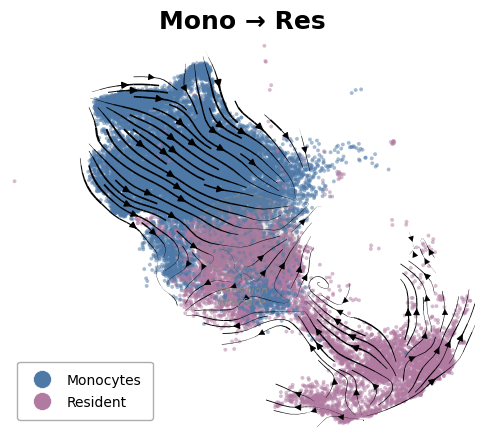


Loading Mono → Scav...
  Shape after cleaning: (41595, 2000)
  ✅ Saved fig3B_Mono_to_Scav.pdf
  ✅ Saved fig3B_Mono_to_Scav.png


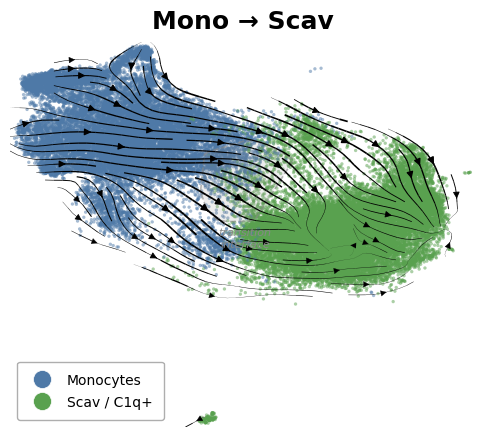


Loading Mono → Fibro...
  Shape after cleaning: (25933, 2000)
  ✅ Saved fig3B_Mono_to_Fibro.pdf
  ✅ Saved fig3B_Mono_to_Fibro.png


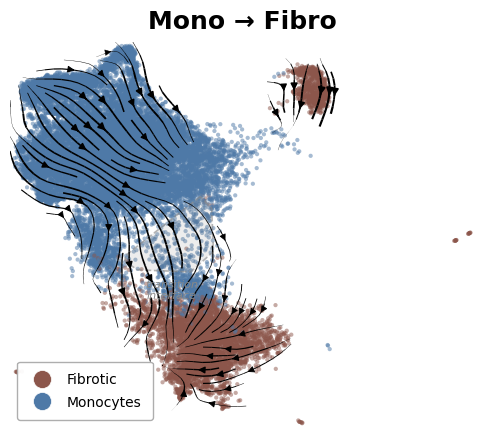


Loading Mono → Foam...
  Shape after cleaning: (29411, 2000)
  ✅ Saved fig3B_Mono_to_Foam.pdf
  ✅ Saved fig3B_Mono_to_Foam.png


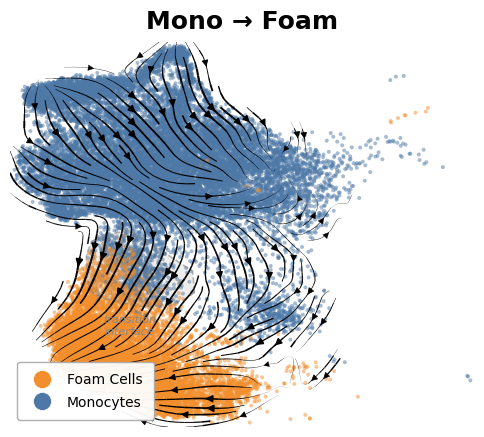


Loading Mono → Inflam...
  Shape after cleaning: (35356, 2000)
  ✅ Saved fig3B_Mono_to_Inflam.pdf
  ✅ Saved fig3B_Mono_to_Inflam.png


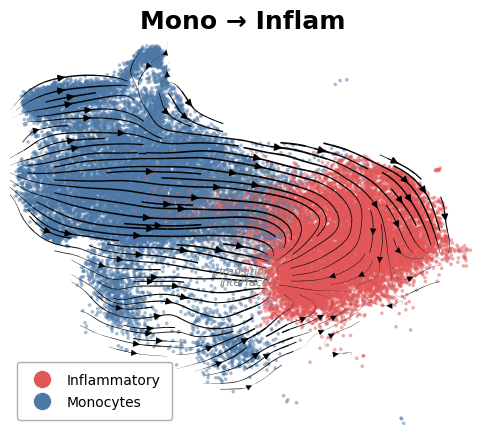


Creating combined 2x3 figure with legend in bottom-right...

Loading Mono → Res for combined figure...

Loading Mono → Scav for combined figure...

Loading Mono → Fibro for combined figure...

Loading Mono → Foam for combined figure...

Loading Mono → Inflam for combined figure...
  ✅ Saved fig3B_combined_2x3_legend.pdf
  ✅ Saved fig3B_combined_2x3_legend.png


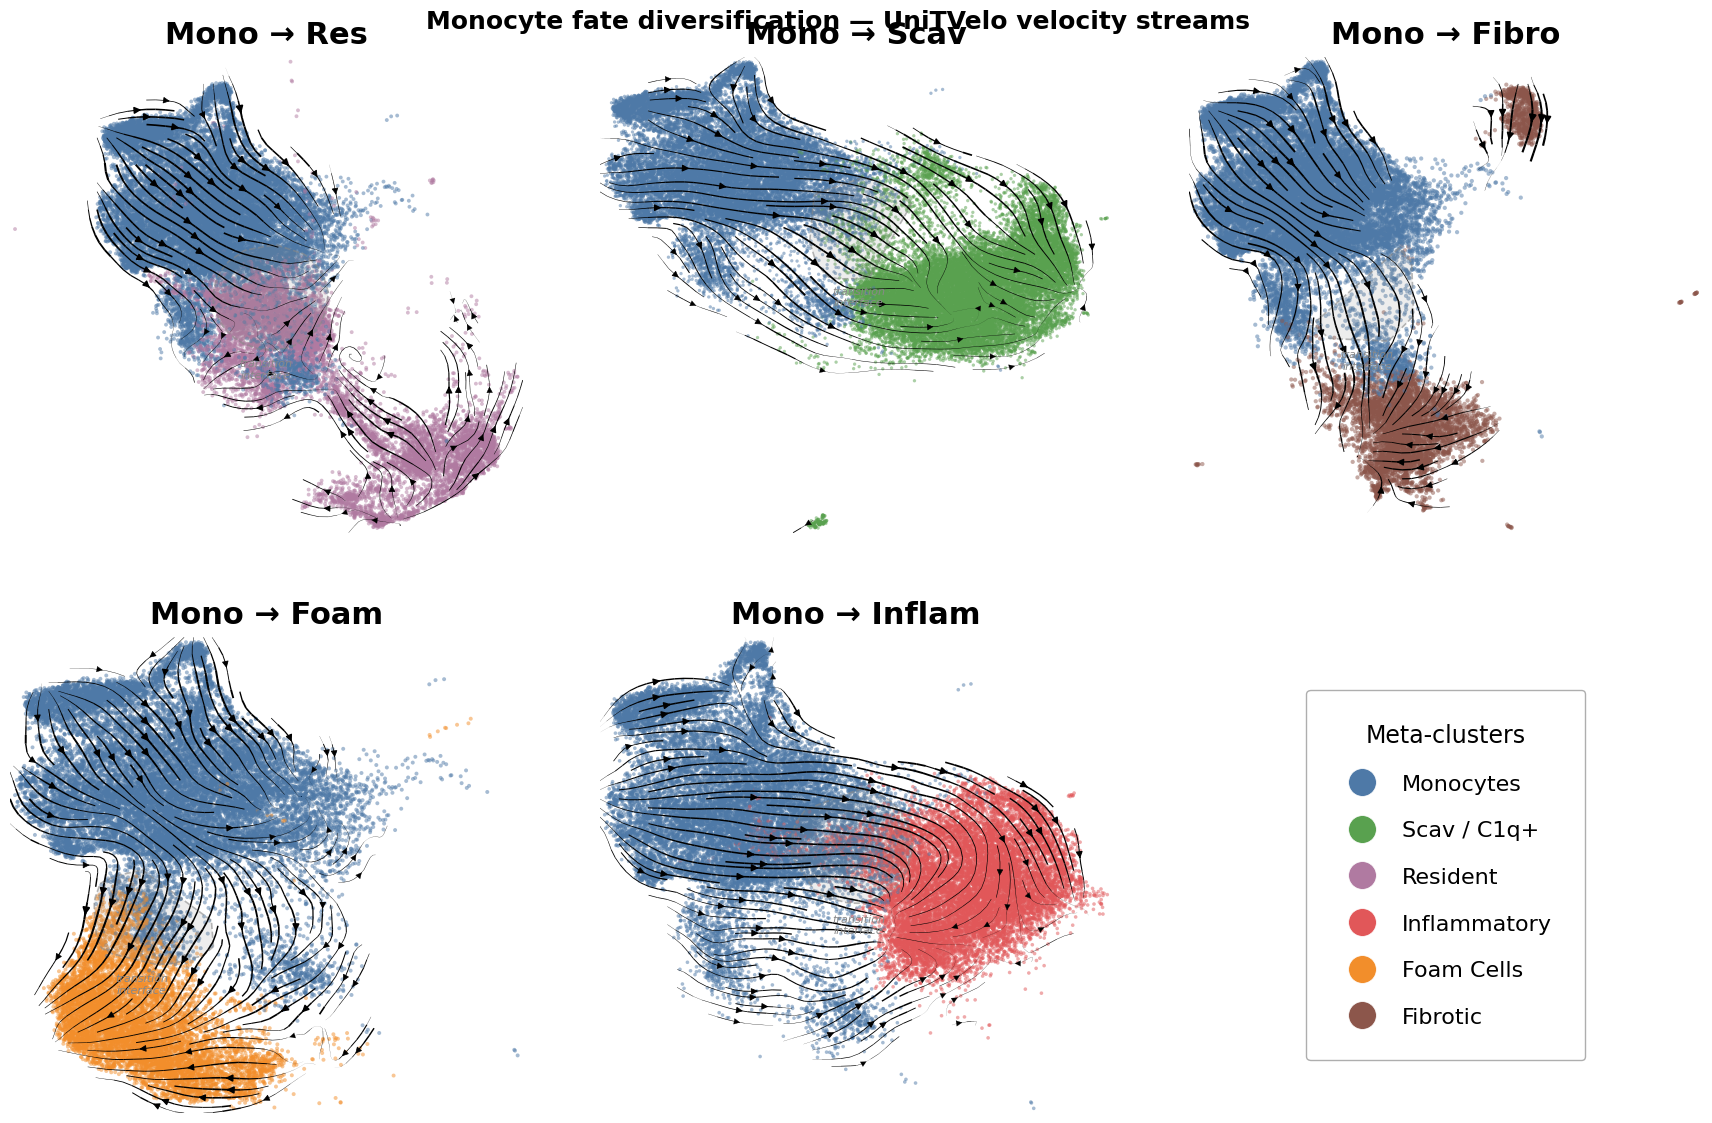


✅ All figures saved to /storage/homefs/sv24v923/MPI_data/clean_pipeline/figures/figure_panels_B


In [10]:
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from pathlib import Path
from scipy.spatial import ConvexHull
from sklearn.neighbors import NearestNeighbors
import gc

scv.settings.verbosity = 1

VELO_DIR = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline/unitvelo_results_META_VALIDATION_V3")
OUT_DIR  = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline/figures/figure_panels_B")
OUT_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "Monocytes":                        "#4E79A7",
    "Scavenging / C1q+ Macrophages":    "#59A14F",
    "Resident / Quiescent Macrophages": "#B07AA1",
    "Inflammatory Macrophages":         "#E15759",
    "Lipid-Stressed / Foam Cells":      "#F28E2B",
    "Fibrotic / Hypoxic Macrophages":   "#8C564B",
}

SHORT_NAMES = {
    "Monocytes":                        "Monocytes",
    "Scavenging / C1q+ Macrophages":    "Scav / C1q+",
    "Resident / Quiescent Macrophages": "Resident",
    "Inflammatory Macrophages":         "Inflammatory",
    "Lipid-Stressed / Foam Cells":      "Foam Cells",
    "Fibrotic / Hypoxic Macrophages":   "Fibrotic",
}

CT_COL = "cell_type_meta_v3"

FIG3_TRANSITIONS = [
    ("Monocytes_to_Resident___Quiescent_Macrophages", "Mono → Res"),
    ("Monocytes_to_Scavenging___C1qp_Macrophages",    "Mono → Scav"),
    ("Monocytes_to_Fibrotic___Hypoxic_Macrophages",   "Mono → Fibro"),
    ("Monocytes_to_Lipid-Stressed___Foam_Cells",      "Mono → Foam"),
    ("Monocytes_to_Inflammatory_Macrophages",         "Mono → Inflam"),
]


def clean_adata(adata):
    finite_mask = np.ones(adata.n_obs, dtype=bool)
    for key in ["X_umap", "velocity_umap", "X_scanorama", "X_diffmap"]:
        if key in adata.obsm:
            arr = adata.obsm[key]
            if hasattr(arr, "toarray"):
                arr = arr.toarray()
            bad = ~np.isfinite(arr).all(axis=1)
            if bad.any():
                print(f"  {key}: {bad.sum()} non-finite cells")
                finite_mask &= ~bad
    n_removed = (~finite_mask).sum()
    if n_removed > 0:
        print(f"  Removing {n_removed} non-finite cells ({n_removed/adata.n_obs*100:.1f}%)")
        adata = adata[finite_mask].copy()
    if "velocity_umap" in adata.obsm:
        adata.obsm["velocity_umap"] = np.nan_to_num(
            adata.obsm["velocity_umap"], nan=0.0, posinf=0.0, neginf=0.0
        )
    return adata


def rasterize_data_artists(ax):
    from matplotlib.collections import PathCollection, LineCollection
    from matplotlib.lines import Line2D
    from matplotlib.patches import FancyArrowPatch
    for artist in ax.get_children():
        if isinstance(artist, (PathCollection, LineCollection, FancyArrowPatch)):
            artist.set_rasterized(True)
        elif isinstance(artist, Line2D):
            if artist.get_xdata().size > 2:
                artist.set_rasterized(True)


def safe_save(fig, path_stem, dpi=300):
    for ax in fig.axes:
        rasterize_data_artists(ax)
    pdf_path = f"{path_stem}.pdf"
    try:
        fig.savefig(pdf_path, bbox_inches="tight", dpi=dpi,
                    format="pdf", backend="pdf")
        print(f"  ✅ Saved {Path(path_stem).name}.pdf")
    except Exception as e:
        print(f"  ⚠ PDF failed: {e}")
    fig.savefig(f"{path_stem}.png", bbox_inches="tight", dpi=300)
    print(f"  ✅ Saved {Path(path_stem).name}.png")


def draw_transition_interface(ax, adata, ct_col, k_neighbors=20,
                               color="#888888", alpha_fill=0.15, expand=0.05,
                               radius_frac=0.25):
    umap  = adata.obsm["X_umap"]
    types = adata.obs[ct_col].values
    cats  = list(adata.obs[ct_col].cat.categories)

    if len(cats) != 2:
        return

    ct_a, ct_b = cats[0], cats[1]

    nbrs = NearestNeighbors(n_neighbors=k_neighbors + 1, algorithm="ball_tree", n_jobs=1)
    nbrs.fit(umap)
    _, indices = nbrs.kneighbors(umap)

    boundary_a = np.zeros(adata.n_obs, dtype=bool)
    boundary_b = np.zeros(adata.n_obs, dtype=bool)

    for idx in np.where(types == ct_a)[0]:
        if ct_b in types[indices[idx, 1:]]:
            boundary_a[idx] = True
    for idx in np.where(types == ct_b)[0]:
        if ct_a in types[indices[idx, 1:]]:
            boundary_b[idx] = True

    boundary_pts = umap[boundary_a | boundary_b]
    if len(boundary_pts) < 4:
        return

    centroid_a   = umap[types == ct_a].mean(axis=0)
    centroid_b   = umap[types == ct_b].mean(axis=0)
    midpoint     = (centroid_a + centroid_b) / 2
    span         = np.linalg.norm(centroid_a - centroid_b)
    radius       = span * radius_frac

    dists_to_mid = np.linalg.norm(boundary_pts - midpoint, axis=1)
    core_pts     = boundary_pts[dists_to_mid < radius]

    if len(core_pts) < 4:
        core_pts = boundary_pts

    centroid = core_pts.mean(axis=0)
    dirs     = core_pts - centroid
    norms    = np.linalg.norm(dirs, axis=1, keepdims=True)
    norms    = np.where(norms == 0, 1, norms)
    expanded = core_pts + expand * (dirs / norms)

    try:
        hull = ConvexHull(expanded)
    except Exception as e:
        print(f"  ⚠ ConvexHull failed: {e}")
        return

    hull_pts = expanded[hull.vertices]
    hull_pts = np.vstack([hull_pts, hull_pts[0]])

    ax.fill(hull_pts[:, 0], hull_pts[:, 1],
            color=color, alpha=alpha_fill, zorder=1.5, linewidth=0)
    ax.plot(hull_pts[:, 0], hull_pts[:, 1],
            color=color, alpha=0.6, linewidth=1.2,
            linestyle="--", zorder=1.6)

    label_x = hull_pts[:, 0].mean()
    label_y = hull_pts[:, 1].min() - 0.3
    ax.text(label_x, label_y, "transition\ninterface",
            ha="center", va="top", fontsize=8, color=color,
            style="italic", zorder=10)


def plot_velocity_panel(adata, ax, title, show_interface=True,
                        show_legend=False, title_fontsize=20):
    cats = adata.obs[CT_COL].cat.categories.tolist()
    adata.uns[f"{CT_COL}_colors"] = [COLORS.get(c, "#CCCCCC") for c in cats]

    scv.pl.velocity_embedding_stream(
        adata, basis="umap", color=CT_COL,
        title="", legend_loc="none", ax=ax, show=False,
        density=1.8, linewidth=0.8, arrow_size=1.0,
        alpha=0.5, min_mass=2.0,
    )

    if show_interface:
        draw_transition_interface(ax, adata, CT_COL)

    if ax.get_legend():
        ax.get_legend().remove()

    if show_legend:
        present_cats = [c for c in cats if c in adata.obs[CT_COL].values]
        handles = [
            plt.Line2D([0], [0], marker="o", color="w",
                       markerfacecolor=COLORS.get(c, "#CCCCCC"),
                       markersize=10, label=SHORT_NAMES.get(c, c),
                       markeredgecolor="white", markeredgewidth=0.5)
            for c in present_cats
        ]
        ax.legend(
            handles=handles,
            fontsize=10, loc="lower left", frameon=True,
            facecolor="white", edgecolor="#AAAAAA",
            framealpha=0.95, markerscale=1.3,
            ncol=1, borderpad=0.8, labelspacing=0.6,
        )

    ax.set_title(title, fontsize=title_fontsize, fontweight="bold", pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")


# ── Individual panels ─────────────────────────────────────────────
for fname_stem, title in FIG3_TRANSITIONS:
    fpath = VELO_DIR / f"unitvelo_pairwise_{fname_stem}.h5ad"
    if not fpath.exists():
        print(f"⚠ Missing: {fpath.name}")
        continue

    print(f"\nLoading {title}...")
    adata = sc.read_h5ad(fpath)
    adata = clean_adata(adata)
    print(f"  Shape after cleaning: {adata.shape}")

    fig, ax = plt.subplots(figsize=(6, 5))
    fig.patch.set_facecolor("white")
    plot_velocity_panel(adata, ax, title, show_legend=True, title_fontsize=18)

    safe_name = title.replace(" → ", "_to_").replace(" ", "")
    safe_save(fig, OUT_DIR / f"fig3B_{safe_name}")
    plt.show()

    del adata
    gc.collect()


# ── Combined figure: 2x3 grid, legend in bottom-right cell ────────
print("\nCreating combined 2x3 figure with legend in bottom-right...")

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("white")

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.22, wspace=0.15,
                       top=0.93, bottom=0.05, left=0.04, right=0.98)

top_axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
]
bottom_axes = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]
legend_ax = fig.add_subplot(gs[1, 2])
legend_ax.axis("off")

top_stems    = FIG3_TRANSITIONS[:3]
bottom_stems = FIG3_TRANSITIONS[3:]
all_panels   = list(zip(top_axes, top_stems)) + list(zip(bottom_axes, bottom_stems))

for ax, (fname_stem, title) in all_panels:
    fpath = VELO_DIR / f"unitvelo_pairwise_{fname_stem}.h5ad"
    if not fpath.exists():
        print(f"⚠ Missing: {fpath.name}")
        ax.axis("off")
        continue

    print(f"\nLoading {title} for combined figure...")
    adata = sc.read_h5ad(fpath)
    adata = clean_adata(adata)
    plot_velocity_panel(adata, ax, title,
                        show_legend=False, title_fontsize=22)
    del adata
    gc.collect()

# Vertical legend in bottom-right cell
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=COLORS[c],
               markersize=20, label=SHORT_NAMES[c],
               markeredgecolor="white", markeredgewidth=0.5)
    for c in COLORS
]

legend_ax.legend(
    handles=legend_handles,
    loc="center",
    ncol=1,
    fontsize=16,
    frameon=True,
    facecolor="white",
    edgecolor="#AAAAAA",
    framealpha=0.95,
    markerscale=1.0,
    borderpad=1.5,
    labelspacing=1.2,
    handletextpad=0.8,
    title="Meta-clusters",
    title_fontsize=17,
)

fig.suptitle(
    "Monocyte fate diversification — UniTVelo velocity streams",
    fontsize=18, fontweight="bold", y=0.97,
)

safe_save(fig, OUT_DIR / "fig3B_combined_2x3_legend")
plt.show()
print(f"\n✅ All figures saved to {OUT_DIR}")

Running 1000 permutations per panel...

  Mono → Inflam — 20,449 cells, 1000 permutations...


  Done in 4.6s
  Gene           Obs FC   Perm p   Sig
  ----------------------------------------
  CCL4           +1.988   0.0010   ***
  CCL3           +1.847   0.0010   ***
  IL1B           +1.506   0.0010   ***
  CXCL8          +1.353   0.0010   ***
  S100A9         -0.590   0.0010   ***
  FCN1           -0.534   0.0010   ***
  NAMPT          +0.367   0.0010   ***
  SAMSN1         +0.343   0.0010   ***

  Mono → Scav — 20,449 cells, 1000 permutations...
  Done in 4.6s
  Gene           Obs FC   Perm p   Sig
  ----------------------------------------
  C1QA           +1.394   0.0010   ***
  C1QB           +1.262   0.0010   ***
  APOE           +1.528   0.0010   ***
  SELENOP        +0.943   0.0010   ***
  S100A9         -0.265   0.0010   ***
  FCN1           -0.230   0.0010   ***
  NAMPT          +0.201   0.0010   ***
  SAMSN1         +0.195   0.0010   ***

  Mono → Foam — 20,449 cells, 1000 permutations...
  Done in 4.2s
  Gene           Obs FC   Perm p   Sig
  ----------------------

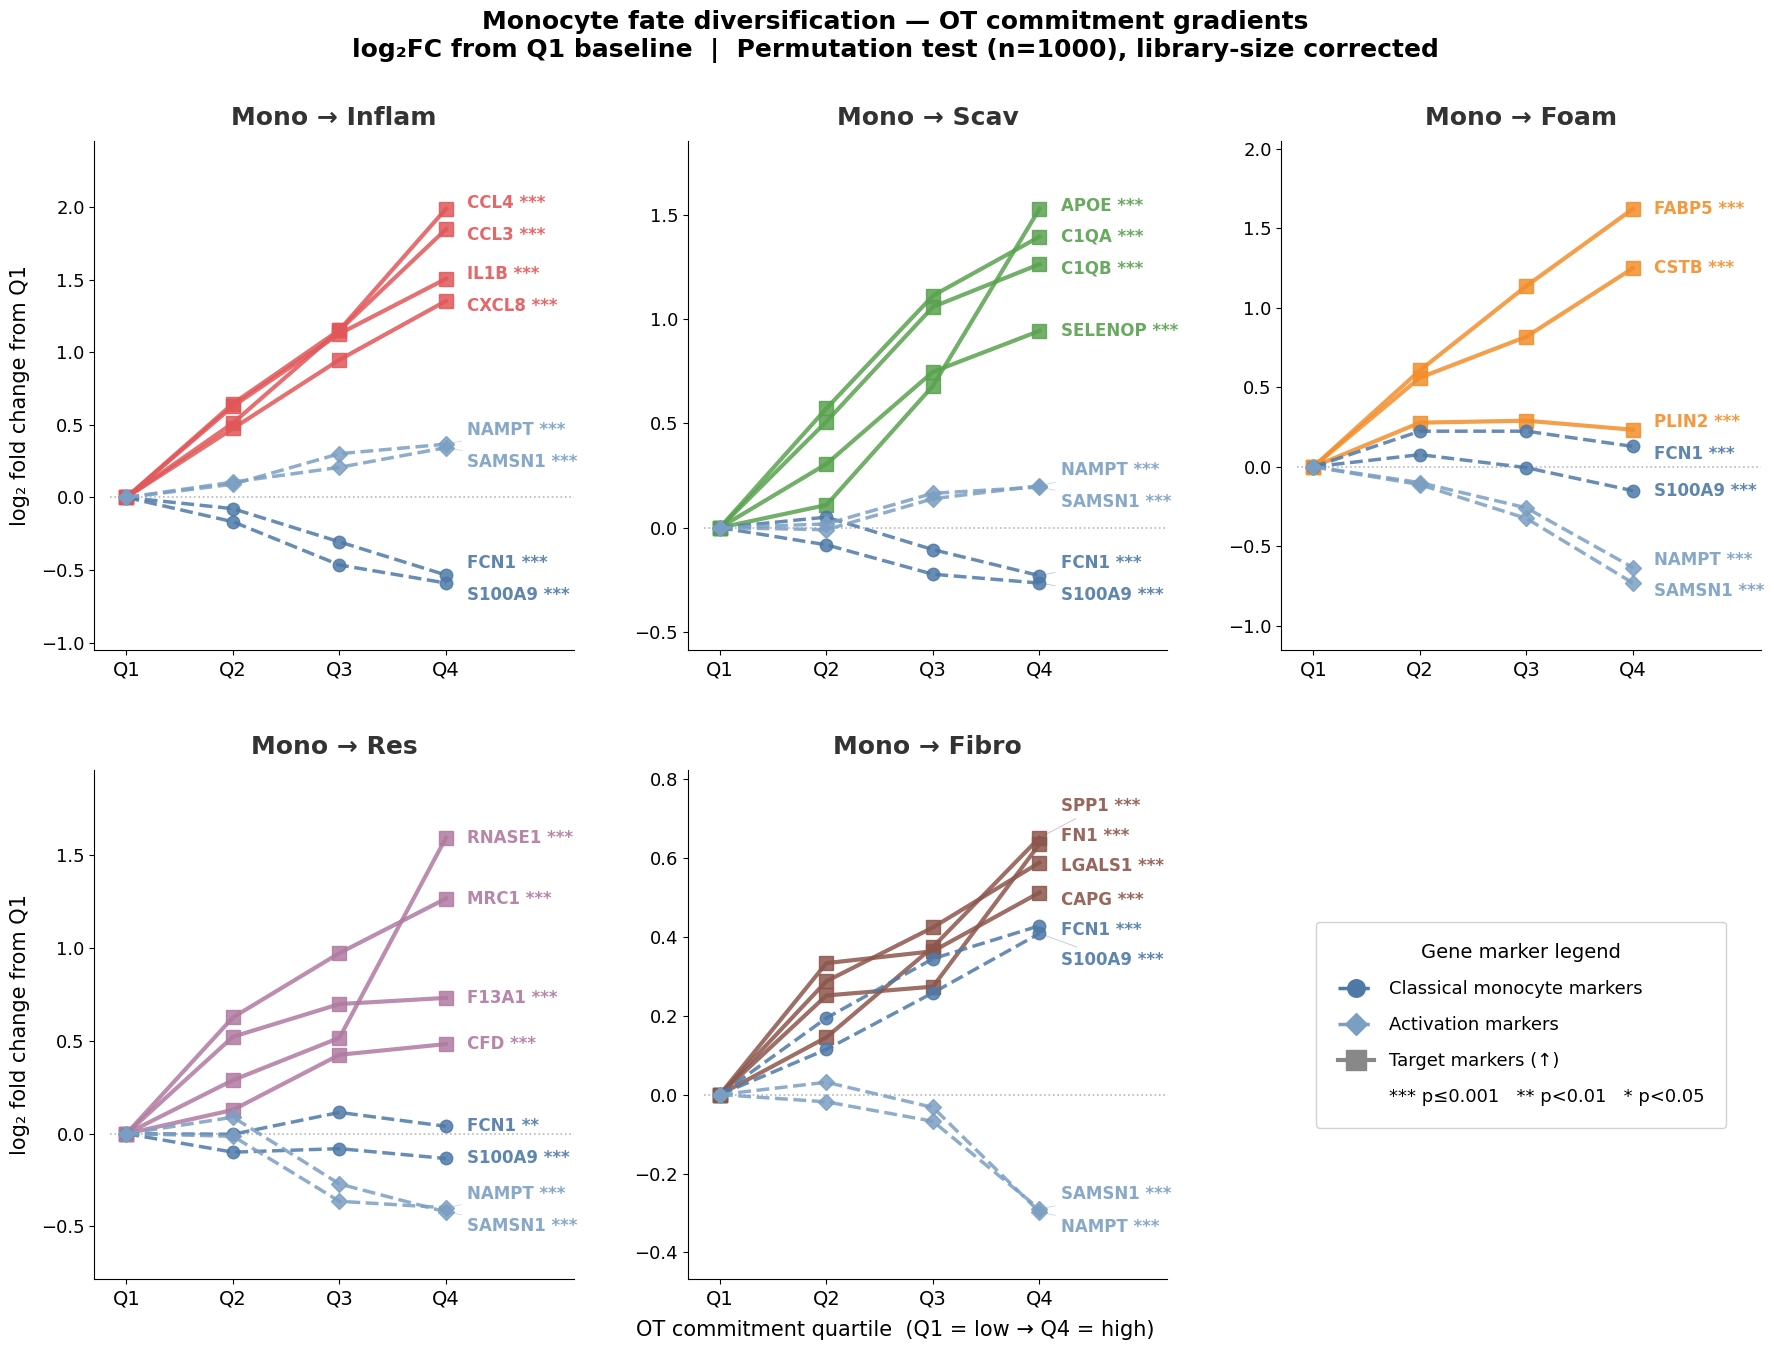

✅ Fig3D saved


In [12]:
# %% FIG 3D — Monocyte fate diversification + permutation test
# Two source-marker programs: classical identity vs activation state
# Permutation test: shuffle OT weights n=1000, recompute Q4/Q1 FC
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import time

BASE          = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
CORRECTED_DIR = BASE / "ot_gradients_v3"
OUT_DIR       = BASE / "figures/figure_panels_D_v5"
OUT_DIR.mkdir(parents=True, exist_ok=True)

Q_ORDER = ["Q1", "Q2", "Q3", "Q4"]
PSEUDO  = 0.1
N_PERM  = 1000

COLORS = {
    "Mono":      "#4E79A7",
    "Scav":      "#59A14F",
    "Res":       "#B07AA1",
    "Inflam":    "#E15759",
    "Foam":      "#F28E2B",
    "Fibro":     "#8C564B",
    "classical": "#4E79A7",
    "activation":"#7B9FC2",
}

# ══════════════════════════════════════════════════════════════════
# STYLE — adjust any of these freely
# ══════════════════════════════════════════════════════════════════
STYLE = {
    # Figure
    "figsize":              (18, 13),
    "h_pad":                4.0,
    "w_pad":                2.5,

    # Marker sizes (per series)
    "ms_target":            10,    # target gene markers (squares)
    "ms_classical":         9,     # classical monocyte markers (circles)
    "ms_activation":        8,     # activation markers (diamonds)

    # Line widths
    "lw_target":            3.0,
    "lw_classical":         2.5,
    "lw_activation":        2.5,
    "lw_zero":              1.2,

    # Subplot title (Mono → ...)
    "title_fontsize":       18,
    "title_pad":            12,

    # Axis tick + label sizes
    "xtick_fontsize":       14,
    "ytick_fontsize":       13,
    "ylabel_fontsize":      15,
    "ylabel_pad":           8,

    # Endpoint gene labels
    "endpoint_fontsize":    12,
    "endpoint_offset_x":    0.20,

    # Legend
    "legend_fontsize":      13,
    "legend_title_fontsize":14,
    "legend_marker_scale":  1.4,

    # Bottom x-axis description
    "xdesc_fontsize":       15,
    "xdesc_y":              -0.01,

    # Suptitle
    "suptitle_fontsize":    18,
    "suptitle_y":           1.01,
}

FIG3D_PANELS = [
    {"csv": "Mono_to_Inflam.csv", "title": "Mono → Inflam", "tgt_type": "Inflam",
     "classical_genes": ["S100A9", "FCN1"], "activation_genes": ["NAMPT", "SAMSN1"],
     "tgt_genes": ["CCL4", "CCL3", "IL1B", "CXCL8"]},
    {"csv": "Mono_to_Scav.csv", "title": "Mono → Scav", "tgt_type": "Scav",
     "classical_genes": ["S100A9", "FCN1"], "activation_genes": ["NAMPT", "SAMSN1"],
     "tgt_genes": ["C1QA", "C1QB", "APOE", "SELENOP"]},
    {"csv": "Mono_to_Foam.csv", "title": "Mono → Foam", "tgt_type": "Foam",
     "classical_genes": ["S100A9", "FCN1"], "activation_genes": ["NAMPT", "SAMSN1"],
     "tgt_genes": ["FABP5", "CSTB", "PLIN2"]},
    {"csv": "Mono_to_Res.csv", "title": "Mono → Res", "tgt_type": "Res",
     "classical_genes": ["S100A9", "FCN1"], "activation_genes": ["NAMPT", "SAMSN1"],
     "tgt_genes": ["RNASE1", "MRC1", "F13A1", "CFD"]},
    {"csv": "Mono_to_Fibro.csv", "title": "Mono → Fibro", "tgt_type": "Fibro",
     "classical_genes": ["S100A9", "FCN1"], "activation_genes": ["NAMPT", "SAMSN1"],
     "tgt_genes": ["SPP1", "LGALS1", "FN1", "CAPG"]},
]

# ── Permutation helpers ────────────────────────────────────────
def perm_stars(p):
    if p <= 0.001: return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

def observed_log2fc(expr, quartile_labels):
    q1 = expr[quartile_labels == "Q1"].mean()
    q4 = expr[quartile_labels == "Q4"].mean()
    return np.log2((q4 + PSEUDO) / (q1 + PSEUDO))

def run_permutation_test(df, genes, n_perm=N_PERM, seed=42):
    rng      = np.random.default_rng(seed)
    weights  = df["ot_weight_corrected"].values.copy()
    avail    = [g for g in genes if g in df.columns]
    expr_mat = df[avail].values.astype(np.float32)
    obs_q    = df["ot_quartile_corrected"].values.astype(str)
    obs_fc   = {gene: observed_log2fc(expr_mat[:, gi], obs_q)
                for gi, gene in enumerate(avail)}
    null_fcs = {gene: [] for gene in avail}
    for _ in range(n_perm):
        shuffled = rng.permutation(weights)
        null_q   = pd.qcut(shuffled, q=4, labels=Q_ORDER).astype(str)
        for gi, gene in enumerate(avail):
            null_fcs[gene].append(observed_log2fc(expr_mat[:, gi], null_q))
    perm_pvals = {}
    for gene in avail:
        null = np.array(null_fcs[gene])
        p    = (np.abs(null) >= np.abs(obs_fc[gene])).mean()
        perm_pvals[gene] = max(p, 1.0 / n_perm)
    return perm_pvals, obs_fc

# ── Load + compute ─────────────────────────────────────────────
def load_panel(panel):
    t0 = time.time()
    df = pd.read_csv(CORRECTED_DIR / panel["csv"])
    all_genes = list(dict.fromkeys(
        panel["tgt_genes"] + panel["classical_genes"] + panel["activation_genes"]))
    missing = [g for g in all_genes if g not in df.columns]
    if missing: print(f"  ⚠ {panel['csv']} missing: {missing}")
    available = [g for g in all_genes if g in df.columns]
    print(f"\n  {panel['title']} — {len(df):,} cells, {N_PERM} permutations...")
    qm = df.groupby("ot_quartile_corrected", observed=True)[available].mean().loc[Q_ORDER]
    qm_fc = pd.DataFrame(index=Q_ORDER, columns=available, dtype=float)
    for gene in available:
        q1_val = qm.loc["Q1", gene]
        for q in Q_ORDER:
            qm_fc.loc[q, gene] = np.log2((qm.loc[q, gene] + PSEUDO) / (q1_val + PSEUDO))
    perm_pvals, obs_fc = run_permutation_test(df, available)
    print(f"  Done in {time.time()-t0:.1f}s")
    print(f"  {'Gene':<12} {'Obs FC':>8} {'Perm p':>8} {'Sig':>5}")
    print(f"  {'-'*40}")
    for gene in available:
        print(f"  {gene:<12} {obs_fc[gene]:>+8.3f} {perm_pvals[gene]:>8.4f} {perm_stars(perm_pvals[gene]):>5}")
    return {"cfg": panel, "qm_fc": qm_fc, "perm_pvals": perm_pvals}

# ── Label spreading ────────────────────────────────────────────
def spread_labels(endpoints, min_gap):
    if not endpoints: return []
    eps       = sorted(enumerate(endpoints), key=lambda t: t[1][0])
    positions = [ep[0] for _, ep in eps]
    indices   = [idx for idx, _ in eps]
    for _ in range(200):
        moved = False
        for i in range(len(positions) - 1):
            gap = positions[i + 1] - positions[i]
            if gap < min_gap:
                shift = (min_gap - gap) / 2 + 0.005
                positions[i] -= shift; positions[i + 1] += shift; moved = True
        if not moved: break
    result = [None] * len(endpoints)
    for si, oi in enumerate(indices): result[oi] = positions[si]
    return result

# ── Plot panel ─────────────────────────────────────────────────
def plot_panel(ax, pd_item):
    cfg, qm_fc, pvals = pd_item["cfg"], pd_item["qm_fc"], pd_item["perm_pvals"]
    x = np.arange(4)
    tgt_col, cls_col, act_col = COLORS[cfg["tgt_type"]], COLORS["classical"], COLORS["activation"]

    all_fc = []
    for g in cfg["tgt_genes"] + cfg["classical_genes"] + cfg["activation_genes"]:
        if g in qm_fc.columns:
            all_fc.extend([float(qm_fc.loc[q, g]) for q in Q_ORDER])
    fc_min, fc_max = (min(all_fc), max(all_fc)) if all_fc else (-1, 1)
    fc_range = max(fc_max - fc_min, 0.5)
    min_gap  = fc_range * 0.08

    def plot_genes(genes, color, marker, ms, lw, ls):
        endpoints = []
        for gene in genes:
            if gene not in qm_fc.columns: continue
            vals = [float(qm_fc.loc[q, gene]) for q in Q_ORDER]
            ax.plot(x, vals, marker=marker, markersize=ms, linewidth=lw,
                    color=color, alpha=0.85, linestyle=ls, zorder=3)
            sig = perm_stars(pvals.get(gene, 1.0))
            label = f"{gene} {sig}" if sig != "ns" else gene
            endpoints.append((vals[3], label, color))
        return endpoints

    tgt_ep = plot_genes(cfg["tgt_genes"],        tgt_col, "s", STYLE["ms_target"],     STYLE["lw_target"],     "-")
    cls_ep = plot_genes(cfg["classical_genes"],  cls_col, "o", STYLE["ms_classical"],  STYLE["lw_classical"],  "--")
    act_ep = plot_genes(cfg["activation_genes"], act_col, "D", STYLE["ms_activation"], STYLE["lw_activation"], "--")

    xlim_right = 4.2
    ax.plot([-0.15, xlim_right], [0, 0], color="#999999",
            linewidth=STYLE["lw_zero"], linestyle=":", zorder=1, alpha=0.7)

    all_endpoints = tgt_ep + cls_ep + act_ep
    y_pad = fc_range * 0.18
    ax.set_ylim(fc_min - y_pad, fc_max + y_pad)
    if all_endpoints:
        raw = [(y, lbl) for (y, lbl, _) in all_endpoints]
        adjusted = spread_labels(raw, min_gap)
        for (raw_y, label, color), label_y in zip(all_endpoints, adjusted):
            use_arrow = abs(raw_y - label_y) > min_gap * 0.4
            ax.annotate(label, xy=(3, raw_y),
                        xytext=(3 + STYLE["endpoint_offset_x"], label_y),
                        fontsize=STYLE["endpoint_fontsize"], fontweight="bold",
                        color=color, va="center", ha="left", alpha=0.9,
                        arrowprops=dict(arrowstyle="-", color=color,
                                        lw=0.6, alpha=0.4) if use_arrow else None)
    ax.set_xticks(x)
    ax.set_xticklabels(Q_ORDER, fontsize=STYLE["xtick_fontsize"])
    ax.set_xlim(-0.3, xlim_right)
    ax.set_title(cfg["title"], fontsize=STYLE["title_fontsize"],
                 fontweight="bold", color="#333", pad=STYLE["title_pad"])
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_facecolor("white")
    ax.tick_params(axis="y", labelsize=STYLE["ytick_fontsize"])

# ── Run ────────────────────────────────────────────────────────
t_total = time.time()
print(f"Running {N_PERM} permutations per panel...")
fig3d_data = [load_panel(p) for p in FIG3D_PANELS]
print(f"\nAll panels done in {(time.time()-t_total)/60:.1f} min")

fig, axes = plt.subplots(2, 3, figsize=STYLE["figsize"])
fig.patch.set_facecolor("white")
for i in range(3): plot_panel(axes[0, i], fig3d_data[i])
for i in range(2): plot_panel(axes[1, i], fig3d_data[3 + i])
axes[0, 0].set_ylabel("log₂ fold change from Q1",
                      fontsize=STYLE["ylabel_fontsize"], labelpad=STYLE["ylabel_pad"])
axes[1, 0].set_ylabel("log₂ fold change from Q1",
                      fontsize=STYLE["ylabel_fontsize"], labelpad=STYLE["ylabel_pad"])

ax_leg = axes[1, 2]; ax_leg.axis("off")
legend_entries = [
    Line2D([0],[0], color=COLORS["classical"],  lw=STYLE["lw_classical"],  ls="--",
           marker="o", ms=STYLE["ms_classical"],  label="Classical monocyte markers"),
    Line2D([0],[0], color=COLORS["activation"], lw=STYLE["lw_activation"], ls="--",
           marker="D", ms=STYLE["ms_activation"], label="Activation markers"),
    Line2D([0],[0], color="#888888",            lw=STYLE["lw_target"],     ls="-",
           marker="s", ms=STYLE["ms_target"],     label="Target markers (↑)"),
    Line2D([0],[0], color="none", marker="None", ls="None",
           label="*** p≤0.001   ** p<0.01   * p<0.05"),
]
ax_leg.legend(handles=legend_entries, loc="center",
              fontsize=STYLE["legend_fontsize"],
              frameon=True, framealpha=0.9, edgecolor="#cccccc",
              title="Gene marker legend",
              title_fontsize=STYLE["legend_title_fontsize"],
              markerscale=STYLE["legend_marker_scale"],
              borderpad=1.2, labelspacing=1.0)

fig.text(0.5, STYLE["xdesc_y"],
         "OT commitment quartile  (Q1 = low → Q4 = high)",
         ha="center", fontsize=STYLE["xdesc_fontsize"])
fig.suptitle(f"Monocyte fate diversification — OT commitment gradients\n"
             f"log₂FC from Q1 baseline  |  Permutation test (n={N_PERM}), library-size corrected",
             fontsize=STYLE["suptitle_fontsize"], fontweight="bold",
             y=STYLE["suptitle_y"])
plt.tight_layout(h_pad=STYLE["h_pad"], w_pad=STYLE["w_pad"])
for ext in ["pdf", "png"]:
    fig.savefig(OUT_DIR / f"fig3D_log2fc_FINAL.{ext}", bbox_inches="tight", dpi=300)
plt.show()
print("✅ Fig3D saved")